# Εργασία Εξαμήνου — Μέρος Α
## Προεπεξεργασία, Embeddings και Εξερευνητική Ανάλυση

**Ονόματα & ΑΜ:**
- Γιώργος Δέλγας , 1115202200036
- Γιώργος Παλαιοκώστας , 1115202200126

In [158]:
%pip install wordcloud nltk vaderSentiment matplotlib scikit-learn pandas numpy --quiet    

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Εισαγωγή Βιβλιοθηκών

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tarfile
import bz2
import os
import nltk

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from wordcloud import WordCloud
from collections import Counter

from gensim.models import Word2Vec
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# Για ομοιόμορφα γραφήματα
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Ορισμός του random seed για αναπαραγωγιμότητα
SEED = 42

print('Βιβλιοθήκες φορτώθηκαν επιτυχώς.')

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


---
## 1. Συλλογή Δεδομένων (Data Collection)

Φορτώνουμε τα 5 αρχεία του dataset και τα συνδέουμε μέσω του κοινού πεδίου `id` (Song ID).  
Στόχος είναι να κρατήσουμε μόνο τα τραγούδια που έχουν δεδομένα και στις 3 κύριες πηγές: **Genre, Audio (MFCC), Lyrics**.

### 1.1 Φόρτωση Genres — Εύρεση Top-5

Κάθε τραγούδι μπορεί να ανήκει σε περισσότερα από ένα genres (comma-separated).  
Κρατάμε το **πρώτο genre** ως κύρια κατηγορία, βρίσκουμε τα 5 πιο συχνά και φιλτράρουμε το dataset.

In [160]:
df_genres = pd.read_csv('id_genres.csv', sep='\t')
print(f'Γραμμές: {len(df_genres)}')
df_genres.head()

Γραμμές: 109269


,id,genres
0,0009fFIM1eYThaPg,pop
1,0010xmHR6UICBOYT,underground hip hop
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock"
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,"post-punk,new wave"


In [161]:
# Κρατάμε το πρώτο genre ως κύριο label
df_genres['primary_genre'] = df_genres['genres'].str.split(',').str[0].str.strip()

# Top-5 genres
top5_genres = df_genres['primary_genre'].value_counts().head(5).index.tolist()
print('Top-5 Genres:', top5_genres)

# Φιλτράρισμα
df_genres_filtered = df_genres[df_genres['primary_genre'].isin(top5_genres)][['id', 'primary_genre']].copy()
df_genres_filtered.rename(columns={'primary_genre': 'genre'}, inplace=True)

print(f'Τραγούδια στα Top-5 Genres: {len(df_genres_filtered)}')
df_genres_filtered['genre'].value_counts()

Top-5 Genres: ['pop', 'rock', 'electronic', 'indie rock', 'folk']
Τραγούδια στα Top-5 Genres: 36175


genre
pop           13621
rock           9286
electronic     5596
indie rock     4003
folk           3669
Name: count, dtype: int64

### 1.2 Φόρτωση Audio Features (MFCC Stats)

Το αρχείο είναι TSV συμπιεσμένο με bz2. Περιέχει 13 MFCC μέσους όρους και τον πίνακα συνδιακύμανσης (flattened upper triangle), συνολικά ~104 features ανά τραγούδι.  
Φιλτράρουμε μόνο τα IDs που μας ενδιαφέρουν για εξοικονόμηση μνήμης.

In [162]:
target_ids = set(df_genres_filtered['id'])

chunks = []
with bz2.open('id_mfcc_stats.tsv.bz2', 'rt') as f:
    for chunk in pd.read_csv(f, sep='\t', chunksize=1000):
        filtered = chunk[chunk['id'].isin(target_ids)]
        if not filtered.empty:
            chunks.append(filtered)

df_mfcc = pd.concat(chunks, ignore_index=True)
print(f'MFCC rows: {len(df_mfcc)}, columns: {len(df_mfcc.columns)}')
df_mfcc.head(2)

MFCC rows: 36175, columns: 105


,id,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,MFCC008,...,cov_9_9,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12
0,9EPCgcAlXdgiFsx4,20.640961,-5.828413,-6.140859,2.526664,-1.409552,2.681575,-2.989035,6.298501,3.528709,...,154.790424,21.799839,-15.056062,-19.218533,109.895439,26.262901,-4.037570,120.298222,18.571392,84.858156
1,9epP1yOXfLKlkR3S,24.351542,-16.611490,-10.792922,0.983246,-4.003687,-0.180248,-1.510487,-0.663130,2.915891,...,57.688839,20.511395,3.479626,-1.560816,63.036257,26.379835,2.551358,55.188890,18.194372,52.472903


### 1.3 Φόρτωση Tags

Τα tags είναι User-Generated Content — δίνουν την «ανθρώπινη» ερμηνεία κάθε τραγουδιού.

In [163]:
df_tags_raw = pd.read_csv('id_tags.csv', sep='\t')
df_tags = df_tags_raw[df_tags_raw['id'].isin(target_ids)][['id', 'tags']].copy()
print(f'Tags rows: {len(df_tags)}')
df_tags.head()

Tags rows: 36175


,id,tags
0,0009fFIM1eYThaPg,"pop,british,female vocalists,dance,cheryl cole"
5,00CH4HJdxQQQbJfu,"indie rock,experimental,indie,chillout,shoegaz..."
8,00IeldeA9ijZOL0P,"pop,bollywood,one world,disney"
9,00KSCJkYb8JKa4Y3,"rock,german,progressive,emo"
10,00LuPWdOccBb09bW,"rock,hard rock,alternative rock,nickelback,roc..."


### 1.4 Φόρτωση Lyrics από tar.gz

Το αρχείο `processed_lyrics.tar.gz` περιέχει ~109k αρχεία κειμένου, ένα ανά τραγούδι (όνομα αρχείου = `{id}.txt`).  
Κάνουμε iterate στο tar και διαβάζουμε **μόνο** τα αρχεία που αντιστοιχούν στα IDs μας.

In [164]:
lyrics_dict = {}

with tarfile.open('processed_lyrics.tar.gz', 'r:gz') as tar:
    for member in tar.getmembers():
        # Εξαγωγή song ID από το όνομα αρχείου (π.χ. processed_lyrics/ABCD1234.txt)
        filename = os.path.basename(member.name)
        if not filename.endswith('.txt'):
            continue
        song_id = filename.replace('.txt', '')
        if song_id in target_ids:
            f = tar.extractfile(member)
            if f:
                lyrics_dict[song_id] = f.read().decode('utf-8', errors='ignore')

df_lyrics = pd.DataFrame(list(lyrics_dict.items()), columns=['id', 'lyrics'])
print(f'Lyrics rows: {len(df_lyrics)}')
df_lyrics.head(2)

Lyrics rows: 36175


,id,lyrics
0,Njp6JPM8vitbhVJU,noth hurt like pain someon love noth gain prep...
1,kVtduoU5M56Amw1M,ladi ladi ladi ladi power ladi ladi ladi ladi ...


### 1.5 Merge — Intersection

Κρατάμε μόνο τα τραγούδια που έχουν δεδομένα **και στα τρία**: Genre, Audio, Lyrics.

In [165]:
df_merged = df_genres_filtered \
    .merge(df_mfcc, on='id') \
    .merge(df_lyrics, on='id') \
    .merge(df_tags, on='id', how='left')  # tags προαιρετικά

print(f'Τελικό dataset: {df_merged.shape[0]} τραγούδια, {df_merged.shape[1]} στήλες')
print(f'Κατανομή genres:')
print(df_merged['genre'].value_counts())
df_merged.head(3)

Τελικό dataset: 36175 τραγούδια, 108 στήλες
Κατανομή genres:
genre
pop           13621
rock           9286
electronic     5596
indie rock     4003
folk           3669
Name: count, dtype: int64


,id,genre,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,...,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12,lyrics,tags
0,0009fFIM1eYThaPg,pop,23.622419,-14.435319,-7.964634,-4.066164,-0.910089,-0.460288,4.683222,2.938227,...,2.908798,-6.870236,116.923098,21.549632,0.300939,110.923613,24.561615,96.538287,sunni day get nowher hide cloud sky pretend ge...,"pop,british,female vocalists,dance,cheryl cole"
1,00CH4HJdxQQQbJfu,indie rock,23.436211,-7.816750,-12.406812,11.062952,-9.058584,-1.206321,-5.282046,-3.253329,...,-36.455772,-2.586953,80.042622,23.692883,-14.386593,92.754345,20.962145,84.711864,crimin walk room ask live way think could woul...,"indie rock,experimental,indie,chillout,shoegaz..."
2,00IeldeA9ijZOL0P,pop,21.568781,-13.389622,-8.882600,-0.269254,-2.845685,0.475457,-0.063772,3.764561,...,22.861579,31.183207,147.867776,51.391861,2.443206,122.146749,39.369417,139.240961,yeah yeah love alway find way everi singl time...,"pop,bollywood,one world,disney"


---
## 2. Εξόρυξη Χαρακτηριστικών & Embeddings (Feature Extraction)

Δημιουργούμε δύο ξεχωριστούς πίνακες χαρακτηριστικών:
- **Audio Embeddings**: Μέσω PCA στα MFCC features
- **Text Embeddings**: Μέσω Word2Vec στους στίχους

### 2.1 Audio Embeddings — PCA

Τα MFCC stats είναι υψηλής διάστασης (~104 features) και θορυβώδη. Εφαρμόζουμε:
1. **Κανονικοποίηση** (StandardScaler) — απαραίτητο πριν PCA
2. **PCA** με 95% διατήρηση variance — μειώνει δραστικά τις διαστάσεις

In [166]:
# Στήλες MFCC (όλες εκτός id, genre, lyrics, tags)
mfcc_cols = [c for c in df_merged.columns if c not in ['id', 'genre', 'lyrics', 'tags']]
print(f'MFCC feature columns: {len(mfcc_cols)}')

X_audio = df_merged[mfcc_cols].values.astype(float)

# Κανονικοποίηση
scaler = StandardScaler()
X_audio_scaled = scaler.fit_transform(X_audio)

# PCA — κράτα 95% variance
pca = PCA(n_components=0.95, random_state=SEED)
X_audio_pca = pca.fit_transform(X_audio_scaled)

print(f'Αρχικές διαστάσεις: {X_audio.shape[1]}')
print(f'Μετά PCA (95% variance): {X_audio_pca.shape[1]}')
print(f'Explained variance ratio (πρώτες 5 components): {pca.explained_variance_ratio_[:5].round(3)}')

MFCC feature columns: 104
Αρχικές διαστάσεις: 104
Μετά PCA (95% variance): 81
Explained variance ratio (πρώτες 5 components): [0.182 0.068 0.039 0.036 0.031]


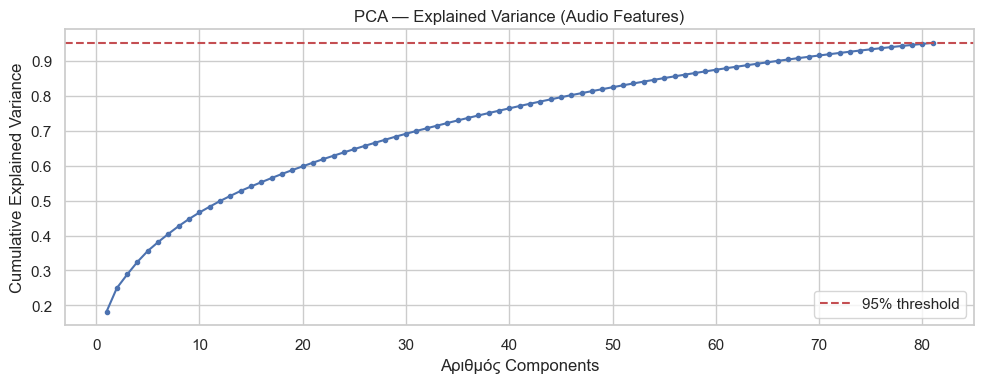

In [167]:
# Γράφημα explained variance (Scree Plot)
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Αριθμός Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Explained Variance (Audio Features)')
plt.legend()
plt.tight_layout()
plt.show()

### 2.2 Text Embeddings — Word2Vec

Εκπαιδεύουμε ένα μοντέλο Word2Vec πάνω στο corpus των στίχων.  
Για κάθε τραγούδι, το embedding είναι ο **μέσος όρος** των word vectors όλων των λέξεων του.

In [168]:
# Tokenization — οι στίχοι είναι ήδη προεπεξεργασμένοι (space-separated tokens)
sentences = [lyric.split() for lyric in df_merged['lyrics'].fillna('')]

# Εκπαίδευση Word2Vec
w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # διάσταση embedding
    window=5,          # context window
    min_count=3,       # αγνόησε λέξεις που εμφανίζονται < 3 φορές
    workers=1,
    seed=SEED,
    epochs=10
)

print(f'Vocabulary size: {len(w2v_model.wv)}')
print(f'Vector size: {w2v_model.vector_size}')

Vocabulary size: 18884
Vector size: 100


In [169]:
def song_to_vector(tokens, model):
    """Μέσος όρος word vectors για ένα τραγούδι."""
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(model.vector_size)

X_text = np.array([
    song_to_vector(tokens, w2v_model)
    for tokens in sentences
])

print(f'Text embeddings shape: {X_text.shape}')

Text embeddings shape: (36175, 100)


---
## 3. Οπτικοποίηση και Ανάλυση (EDA)

Εξερευνούμε τα δεδομένα μέσω γραφημάτων για να κατανοήσουμε τη δομή τους πριν το modeling.

### 3.1 Κατανομή Genres (Bar Chart)

Πρώτη ματιά στο πόσα τραγούδια έχουμε ανά genre.

C:\Users\GIORGOS\AppData\Local\Temp\ipykernel_71560\3561522554.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='Set2')


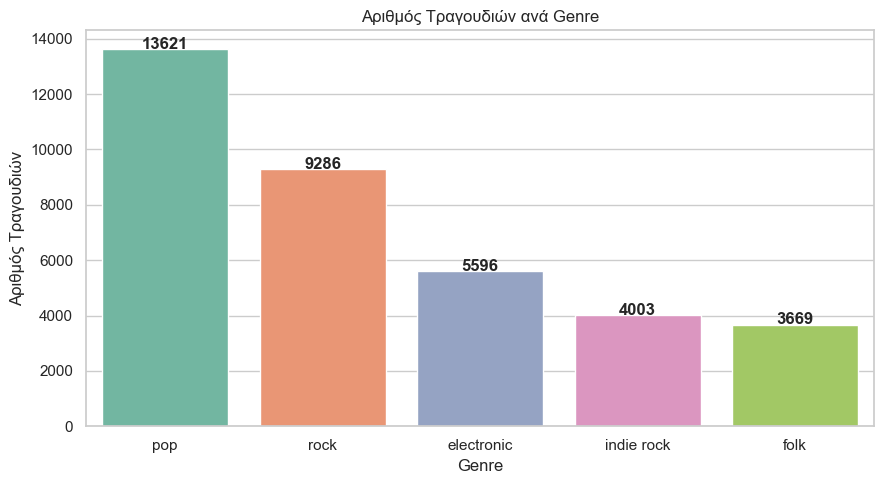

In [170]:
genre_counts = df_merged['genre'].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='Set2')
plt.title('Αριθμός Τραγουδιών ανά Genre')
plt.xlabel('Genre')
plt.ylabel('Αριθμός Τραγουδιών')
for i, v in enumerate(genre_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Top-10 Tags (Bar Chart)

Τα tags είναι User-Generated Content. Βλέπουμε ποια tags εμφανίζονται πιο συχνά σε ολόκληρο το dataset.

C:\Users\GIORGOS\AppData\Local\Temp\ipykernel_71560\835521627.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(tag_values), y=list(tag_labels), palette='Blues_r', orient='h')


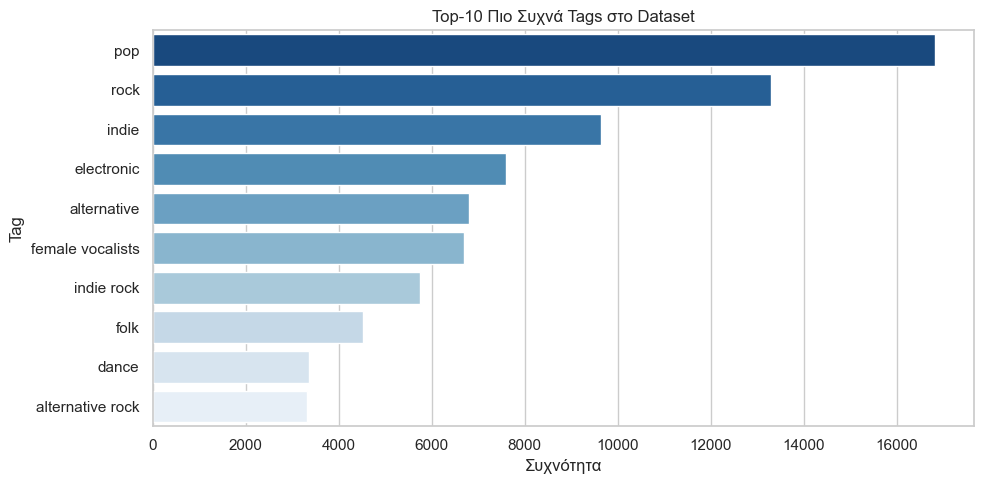

In [171]:
# Συλλογή όλων των tags
all_tags = []
for tags_str in df_merged['tags'].dropna():
    all_tags.extend([t.strip() for t in tags_str.split(',')])

tag_counts = Counter(all_tags)
top10_tags = tag_counts.most_common(10)
tag_labels, tag_values = zip(*top10_tags)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(tag_values), y=list(tag_labels), palette='Blues_r', orient='h')
plt.title('Top-10 Πιο Συχνά Tags στο Dataset')
plt.xlabel('Συχνότητα')
plt.ylabel('Tag')
plt.tight_layout()
plt.show()

### 3.3 Word Clouds ανά Genre

Επιλέγουμε τα 2 πιο διαφορετικά genres και δημιουργούμε Word Cloud από τα tags τους.  
Τα word clouds αποκαλύπτουν την «ταυτότητα» κάθε genre μέσα από τη γλώσσα των χρηστών.

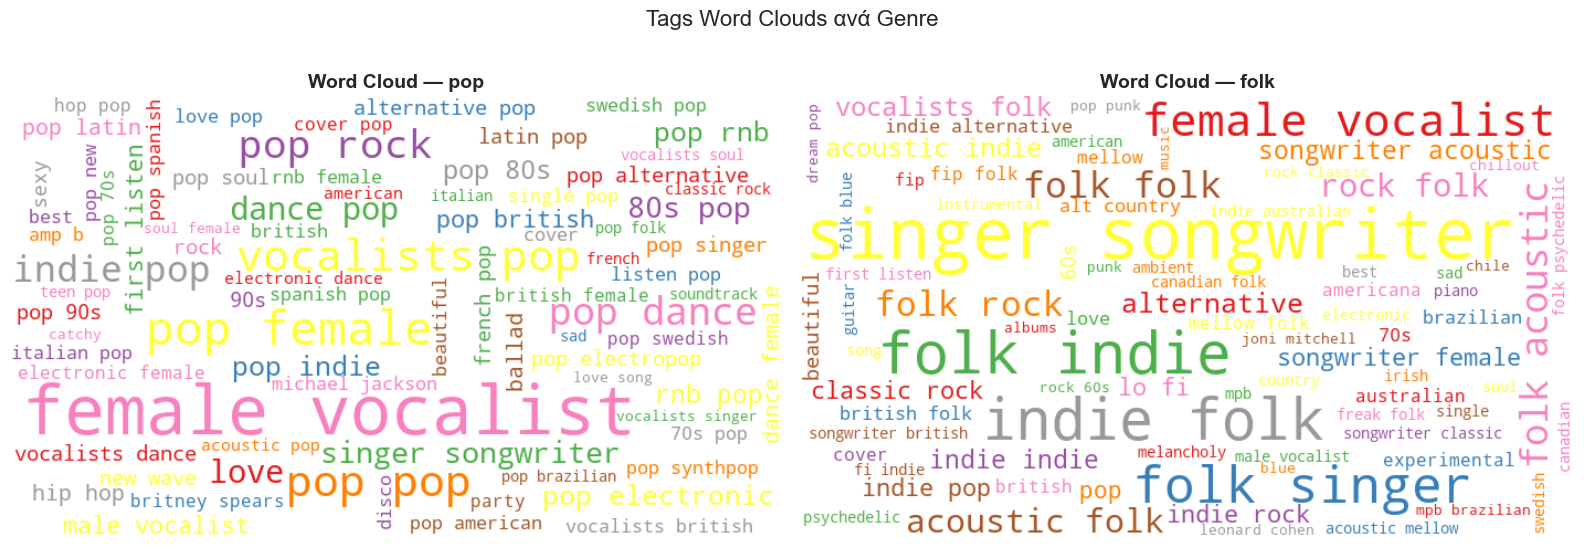

In [172]:
# Επιλογή 2 genres για σύγκριση (άλλαξε αν θες διαφορετικά)
genre_pair = [top5_genres[0], top5_genres[-1]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, genre in zip(axes, genre_pair):
    genre_tags = []
    mask = (df_merged['genre'] == genre) & df_merged['tags'].notna()
    for tags_str in df_merged.loc[mask, 'tags']:
        genre_tags.extend([t.strip() for t in tags_str.split(',')])
    
    text = ' '.join(genre_tags)
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap='Set1', max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud — {genre}', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Tags Word Clouds ανά Genre', fontsize=16)
plt.tight_layout()
plt.show()

### 3.4 Ποικιλία Genres ανά Τραγούδι

Πολλά τραγούδια δεν κατατάσσονται αποκλειστικά σε ένα genre — αντιθέτως "πάλλονται" μεταξύ ειδών.  
Το παρακάτω διάγραμμα δείχνει πόσα τραγούδια ανήκουν σε 1, 2, 3, ... διαφορετικά genres (χωρίς duplicates).  
Χρησιμοποιούμε το **πλήρες** `id_genres.csv` (όχι μόνο τα Top-5 filtered) για να έχουμε πλήρη εικόνα.

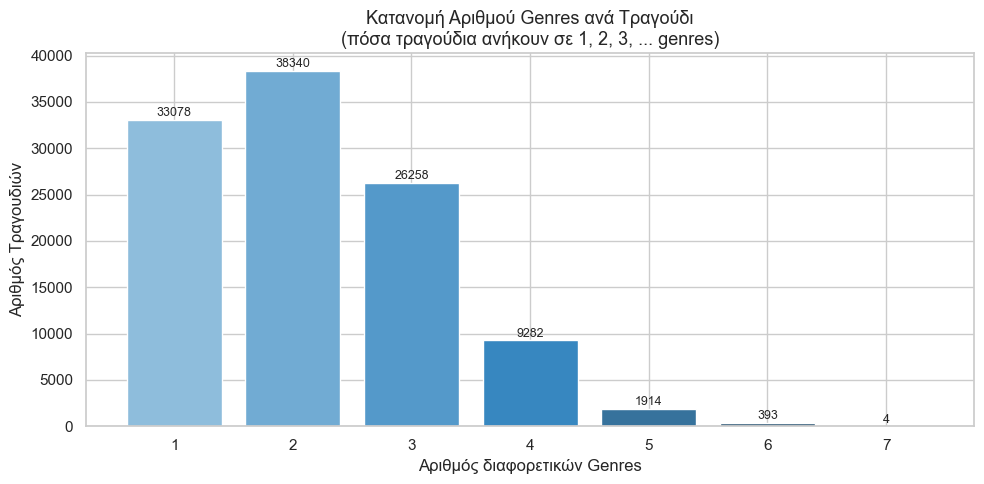

Τραγούδια με μόνο 1 genre: 33078 (30.3%)
Τραγούδια με 2 genres:    38340 (35.1%)
Τραγούδια με 3 genres:    26258 (24.0%)
Τραγούδια με 4 genres:    9282 (8.5%)
Τραγούδια με 5+ genres:   2311 (2.1%)


In [173]:
# Πλήθος μοναδικών genres ανά τραγούδι (χωρίς duplicates)
genre_variety = df_genres['genres'].str.split(',').apply(
    lambda x: len(set([g.strip() for g in x]))
)

# Ομαδοποίηση: 1, 2, ..., 9, 10+
bins = genre_variety.clip(upper=10)
counts = bins.value_counts().sort_index()
labels = [str(i) if i < 10 else '10+' for i in counts.index]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, counts.values, color=sns.color_palette('Blues_d', len(labels)), edgecolor='white')
plt.title('Κατανομή Αριθμού Genres ανά Τραγούδι\n(πόσα τραγούδια ανήκουν σε 1, 2, 3, ... genres)', fontsize=13)
plt.xlabel('Αριθμός διαφορετικών Genres')
plt.ylabel('Αριθμός Τραγουδιών')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

only_one = (genre_variety == 1).sum()
multi_2 = (genre_variety == 2).sum()
multi_3 = (genre_variety == 3).sum()
multi_4 = (genre_variety == 4).sum()
multi_5 = (genre_variety >= 5).sum()
print(f'Τραγούδια με μόνο 1 genre: {only_one} ({only_one/len(genre_variety)*100:.1f}%)')
print(f'Τραγούδια με 2 genres:    {multi_2} ({multi_2/len(genre_variety)*100:.1f}%)')
print(f'Τραγούδια με 3 genres:    {multi_3} ({multi_3/len(genre_variety)*100:.1f}%)')
print(f'Τραγούδια με 4 genres:    {multi_4} ({multi_4/len(genre_variety)*100:.1f}%)')
print(f'Τραγούδια με 5+ genres:   {multi_5} ({multi_5/len(genre_variety)*100:.1f}%)')

### 3.5 Top-N Genres στο Πλήρες Dataset

Το αντίστροφο ερώτημα: αντί να δούμε πόσα genres έχει κάθε τραγούδι, βλέπουμε **πόσα τραγούδια έχει κάθε genre** στο σύνολο του dataset.  
Χρησιμοποιούμε μοναδικά genres ανά τραγούδι (αφαίρεση duplicates) για σωστή καταμέτρηση.

C:\Users\GIORGOS\AppData\Local\Temp\ipykernel_71560\2864633546.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, palette='rocket_r', orient='h')


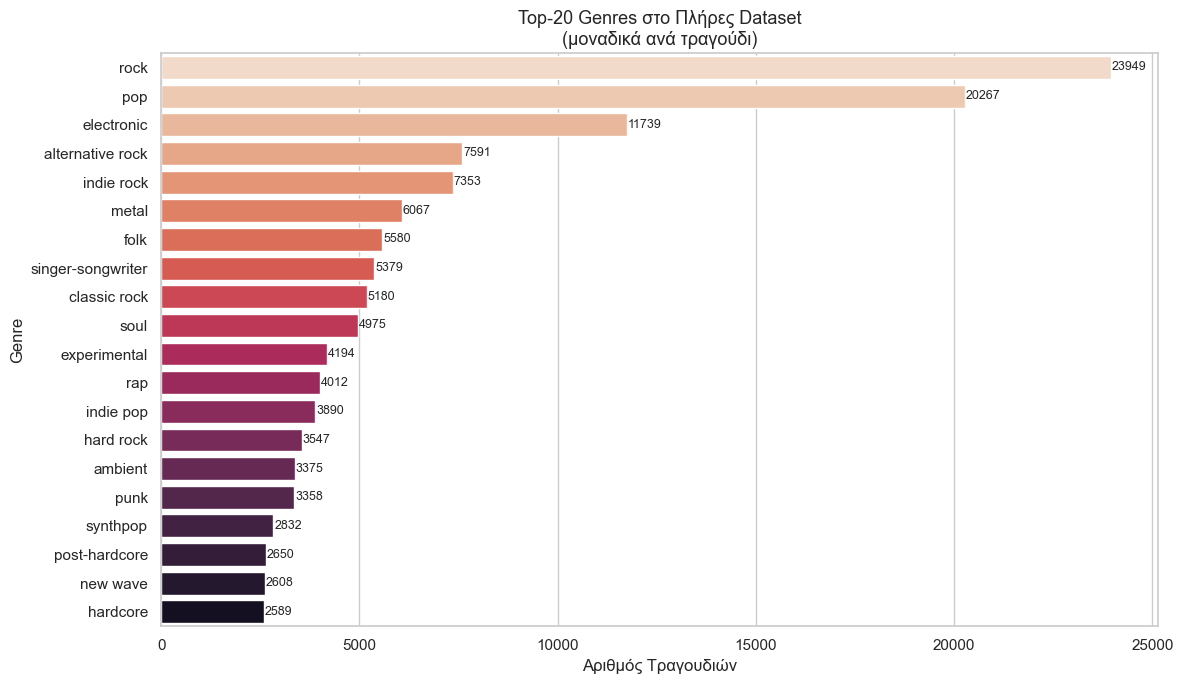

In [174]:
# Top-N genres μετρώντας μοναδικά genres ανά τραγούδι (χωρίς duplicates)
df_genres_full = pd.read_csv('id_genres.csv', sep='\t')
df_genres_full['genre_list'] = df_genres_full['genres'].str.split(',').apply(
    lambda x: list(set([g.strip() for g in x]))
)
all_genres_flat = df_genres_full.explode('genre_list')['genre_list']
top20 = all_genres_flat.value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top20.values, y=top20.index, palette='rocket_r', orient='h')
plt.title('Top-20 Genres στο Πλήρες Dataset\n(μοναδικά ανά τραγούδι)', fontsize=13)
plt.xlabel('Αριθμός Τραγουδιών')
plt.ylabel('Genre')
for i, v in enumerate(top20.values):
    plt.text(v + 20, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 3.6 Κατανομή Μεγέθους Στίχων

Εξετάζουμε πόσο "πλούσια" σε λέξεις είναι τα τραγούδια:
- **Πλήθος λέξεων** και **χαρακτήρων** ανά τραγούδι
- Μετά αφαίρεση **stopwords** (the, a, is, ...) → πόσες ουσιαστικές λέξεις απομένουν

Τα histograms κόβονται στο 99ο percentile για να αποφύγουμε ακραίες τιμές.

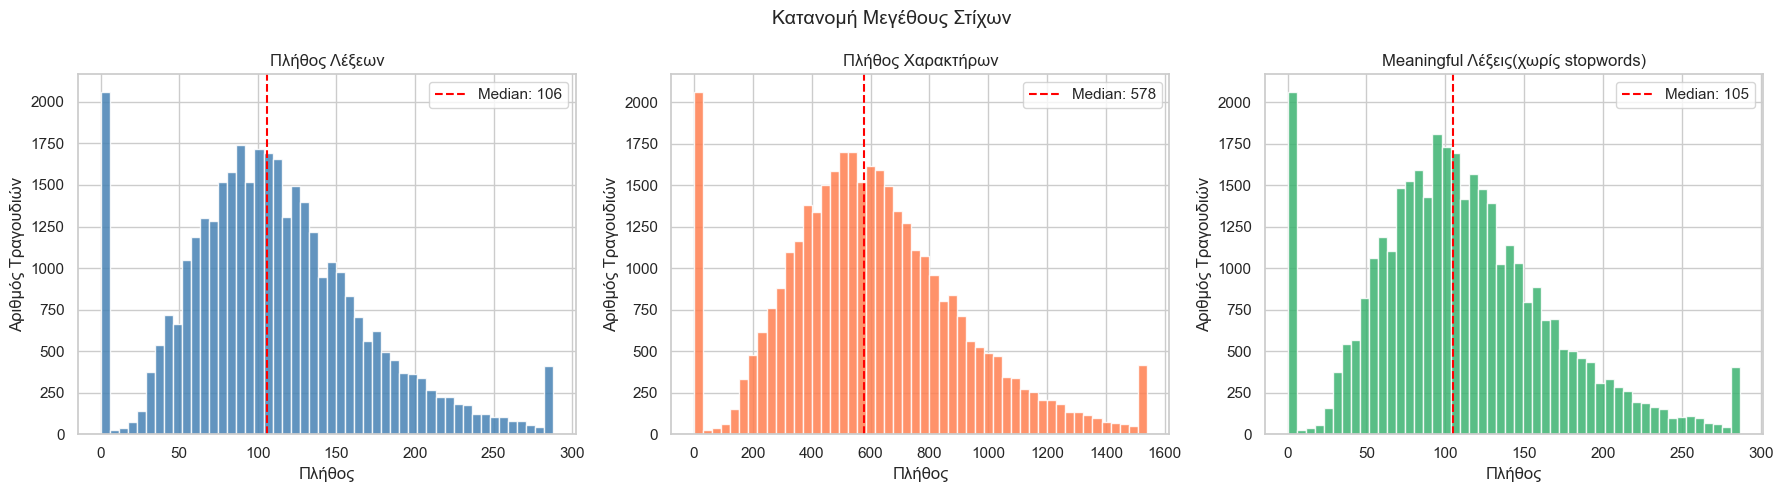

       word_count  char_count  meaningful_words
count     36175.0     36175.0           36175.0
mean        111.2       604.2             110.8
std          63.7       330.8              61.6
min           0.0         0.0               0.0
25%          73.0       400.0              73.0
50%         106.0       578.0             105.0
75%         143.0       778.0             143.0
max        2255.0     11293.0            2255.0


In [175]:
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

# Υπολογισμός στατιστικών στίχων
df_merged['word_count'] = df_merged['lyrics'].fillna('').apply(lambda x: len(x.split()))
df_merged['char_count'] = df_merged['lyrics'].fillna('').apply(len)
df_merged['meaningful_words'] = df_merged['lyrics'].fillna('').apply(
    lambda x: len([w for w in x.split() if w.lower() not in stop_words])
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title, color in zip(
    axes,
    ['word_count', 'char_count', 'meaningful_words'],
    ['Πλήθος Λέξεων', 'Πλήθος Χαρακτήρων', 'Meaningful Λέξεις(χωρίς stopwords)'],
    ['steelblue', 'coral', 'mediumseagreen']
):
    ax.hist(df_merged[col].clip(upper=df_merged[col].quantile(0.99)), bins=50,
            color=color, edgecolor='white', alpha=0.85)
    median_val = df_merged[col].median()
    ax.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.0f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Πλήθος')
    ax.set_ylabel('Αριθμός Τραγουδιών')
    ax.legend()

plt.suptitle('Κατανομή Μεγέθους Στίχων', fontsize=14)
plt.tight_layout()
plt.show()

print(df_merged[['word_count', 'char_count', 'meaningful_words']].describe().round(1))

### 3.7 Sentiment Analysis ανά Genre (VADER)

Χρησιμοποιούμε το **VADER** , ένα pre-trained εργαλείο ανάλυσης συναισθήματος ειδικά σχεδιασμένο για κείμενα social media/lyrics.  
Εξετάζουμε αν επιβεβαιώνεται η υπόθεση: *"Pop = χαρούμενο, Rock/Metal = αρνητικό"*.


C:\Users\GIORGOS\AppData\Local\Temp\ipykernel_71560\1758767774.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='genre', y='sentiment', order=order, palette='RdYlGn')


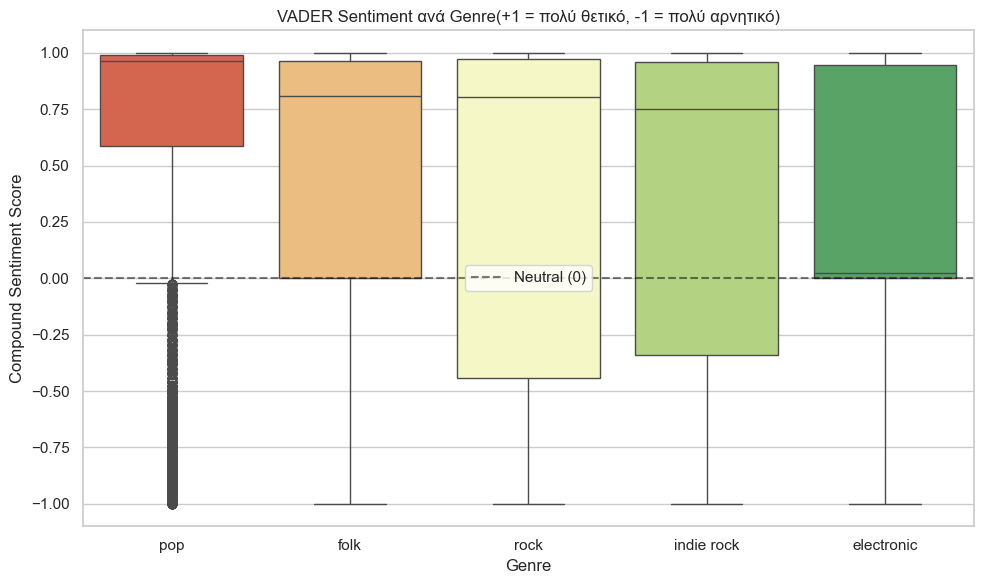

genre
pop           0.592
folk          0.421
indie rock    0.336
rock          0.333
electronic    0.261
Name: sentiment, dtype: float64


In [176]:
analyzer = SentimentIntensityAnalyzer()

#Compound score: +1 = πολύ θετικό, -1 = πολύ αρνητικό
df_merged['sentiment'] = df_merged['lyrics'].fillna('').apply(
lambda x: analyzer.polarity_scores(x)['compound']
)

#Boxplot sentiment ανά genre
plt.figure(figsize=(10, 6))
order = df_merged.groupby('genre')['sentiment'].median().sort_values(ascending=False).index
sns.boxplot(data=df_merged, x='genre', y='sentiment', order=order, palette='RdYlGn')
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Neutral (0)')
plt.title('VADER Sentiment ανά Genre(+1 = πολύ θετικό, -1 = πολύ αρνητικό)')
plt.xlabel('Genre')
plt.ylabel('Compound Sentiment Score')
plt.legend()
plt.tight_layout()
plt.show()

print(df_merged.groupby('genre')['sentiment'].mean().sort_values(ascending=False).round(3))

### 3.8 Dimensionality Reduction — t-SNE Visualization

Εφαρμόζουμε t-SNE για να μειώσουμε τα embeddings σε 2D και να δούμε αν τα genres σχηματίζουν διακριτές συστάδες.  
Συγκρίνουμε **Audio** vs **Text** embeddings — ποια modality διαχωρίζει καλύτερα τις κλάσεις;

In [177]:
# t-SNE σε υποσύνολο για ταχύτητα (αν το dataset είναι μεγάλο)
N_SAMPLE = min(3000, len(df_merged))
idx = np.random.RandomState(SEED).choice(len(df_merged), N_SAMPLE, replace=False)

X_audio_sample = X_audio_pca[idx]
X_text_sample  = X_text[idx]
genres_sample  = df_merged['genre'].values[idx]

print(f'Υποσύνολο για t-SNE: {N_SAMPLE} τραγούδια')

Υποσύνολο για t-SNE: 3000 τραγούδια


In [178]:
# t-SNE για Audio
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
audio_2d = tsne.fit_transform(X_audio_sample)
print('Audio t-SNE done.')

Audio t-SNE done.


In [179]:
# t-SNE για Text
tsne2 = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
text_2d = tsne2.fit_transform(X_text_sample)
print('Text t-SNE done.')

Text t-SNE done.


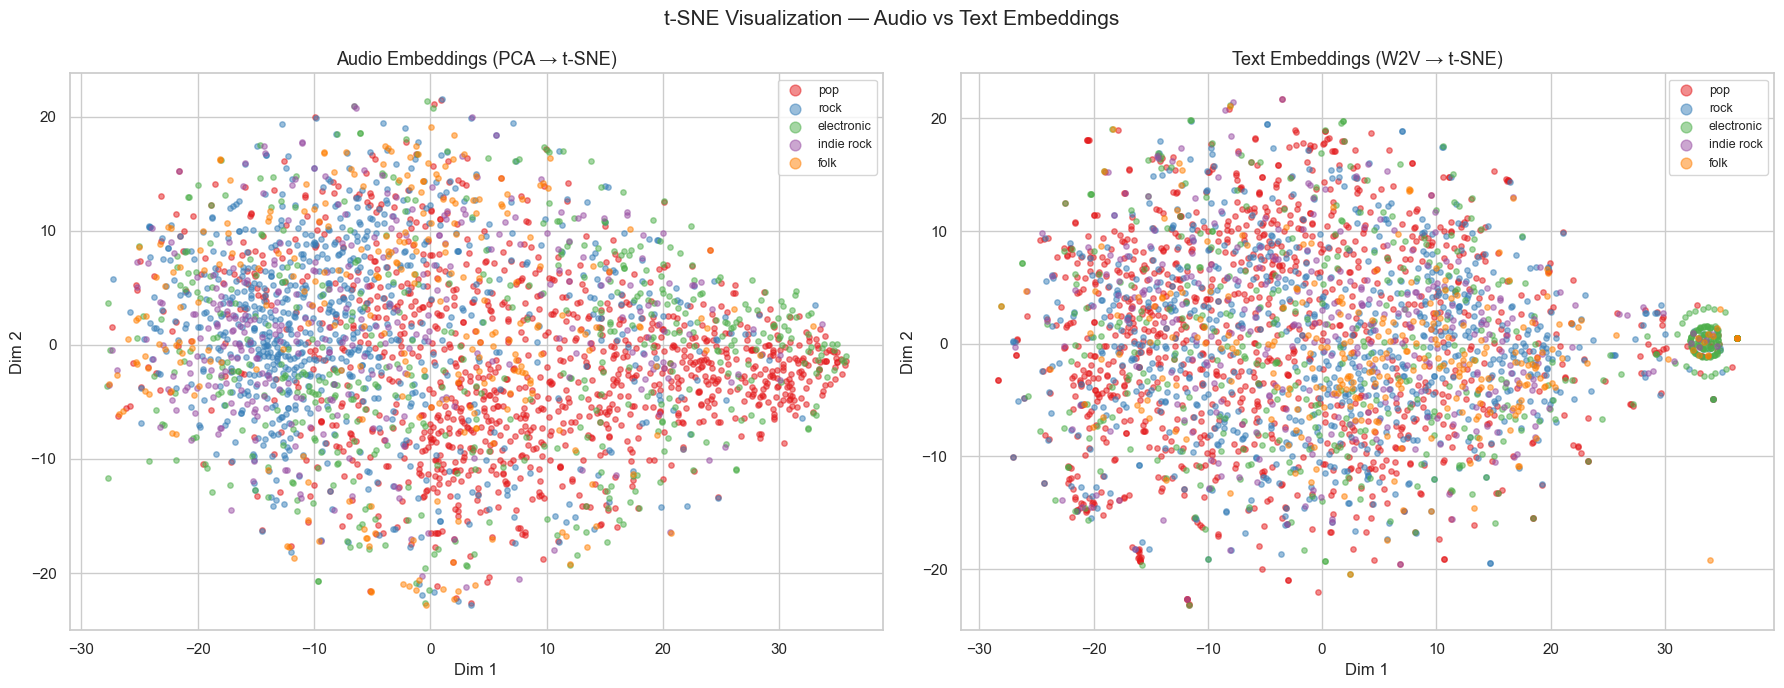

In [180]:
palette = sns.color_palette('Set1', n_colors=len(top5_genres))
genre_color = {g: palette[i] for i, g in enumerate(top5_genres)}
colors = [genre_color[g] for g in genres_sample]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data_2d, title in zip(axes,
                               [audio_2d, text_2d],
                               ['Audio Embeddings (PCA → t-SNE)', 'Text Embeddings (W2V → t-SNE)']):
    for genre in top5_genres:
        mask = genres_sample == genre
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
                   c=[genre_color[genre]], label=genre, alpha=0.5, s=15)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.legend(markerscale=2, fontsize=9)

plt.suptitle('t-SNE Visualization — Audio vs Text Embeddings', fontsize=15)
plt.tight_layout()
plt.show()

**Παρατήρηση:** (Συμπλήρωσε εδώ τα συμπεράσματά σου)
Π.χ. «Τα Audio embeddings παρουσιάζουν [καλύτερο/χειρότερο] διαχωρισμό...» 

### 3.9 Similarity Analysis — Cosine Similarity

Δοθέντος ενός τραγουδιού, βρίσκουμε τα 5 πιο «όμοια» τραγούδια:  
- Πρώτα βάσει **στίχων** (Text Embeddings)
- Μετά βάσει **ήχου** (Audio Embeddings)

Η Cosine Similarity μετράει τη γωνία μεταξύ δύο διανυσμάτων — τιμές κοντά στο 1 σημαίνουν μεγάλη ομοιότητα.

In [181]:
def find_similar_songs(query_idx, embeddings, df, top_n=5):
    """Βρίσκει τα top_n πιο όμοια τραγούδια βάσει cosine similarity."""
    query_vec = embeddings[query_idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, embeddings)[0]
    sims[query_idx] = -1  # εξαίρεση του ίδιου τραγουδιού
    top_indices = np.argsort(sims)[::-1][:top_n]
    results = df.iloc[top_indices][['id', 'genre']].copy()
    results['cosine_similarity'] = sims[top_indices].round(4)
    return results

# Επιλογή τυχαίου τραγουδιού-ερωτήματος
query_idx = 0
query_song = df_merged.iloc[query_idx]
print(f"Query song — ID: {query_song['id']}, Genre: {query_song['genre']}")
print()

Query song — ID: 0009fFIM1eYThaPg, Genre: pop



In [182]:
print('=== Top-5 Όμοια βάσει ΣΤΙΧΩΝ (Text Embeddings) ===')
display(find_similar_songs(query_idx, X_text, df_merged))

print('\n=== Top-5 Όμοια βάσει ΗΧΟΥ (Audio Embeddings) ===')
display(find_similar_songs(query_idx, X_audio_pca, df_merged))

=== Top-5 Όμοια βάσει ΣΤΙΧΩΝ (Text Embeddings) ===


,id,genre,cosine_similarity
6843,Bp2C0upIsbgDIj6g,pop,0.9437
28723,nMWxakz2ha5Qtlk8,rock,0.9043
5914,ADoeKL7oT9iBfak3,pop,0.9038
12926,MKXZ24rbDRjuRcPR,pop,0.9032
9956,HFLuvJXc6SjcJt7d,pop,0.9014



=== Top-5 Όμοια βάσει ΗΧΟΥ (Audio Embeddings) ===


,id,genre,cosine_similarity
32175,tFGgxBWeAQKBRKO8,pop,0.5863
11936,Ke7XhgSrvYsGgyNQ,pop,0.5822
17743,UMahojluDMtosnva,pop,0.5262
15656,QnJ5yd9l0h9c1eqY,pop,0.5251
3370,5h3b3SBGX8XxeGxI,pop,0.5224


**Σχολιασμός:** 